# Business Problem  
As a marketing agency, our primary objective is to maintain the return on investment(ROI) for our clients advertising campaigns/ We have conducted many ad campaigns on social media platforms and we need to determing which platform yeild better result in terms of click, conversion and overall cost-effectiveness. By identifying the most effective platform  we can also allocate our resources more efficiently and optimize our advertising stregies to deiver better outcomes for our clients.


# Research Question

Which ad platform is more effective in terms of coversion, clicks and overall cost-effectiveness?


# Importing Libraries


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import coint
import warnings
warnings.filterwarnings('ignore')

from scipy import stats

In [2]:
# loading dataset
mk_cp = pd.read_csv('nykaa_campaign_data (1).csv')
mk_cp.head(5)


,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,111.03,6.14,Hindi,20.98,College Students,29-04-2025
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,180.83,3.26,Hindi,7.24,College Students,06-04-2025
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,90.60,1.88,English,25.03,College Students,14-01-2025
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,249.07,0.60,Hindi,13.15,College Students,04-06-2025
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,228.60,0.80,Hindi,7.29,Tier 2 City Customers,29-12-2024


# Data Discription


This dataset captures the performance metrics of multiple marketing campaigns across different channels, audiences, and timeframes. It is designed to evaluate campaign effectiveness, customer engagement, and return on investment.

 Campaign_ID	:- Unique identifier assigned to each marketing campaign.
 
Campaign_Type :-	Type of campaign (e.g., Email, Social Media, Paid Ads, Influencer).

Target_Audience	:- Demographic or segment targeted (e.g., Students, Professionals, SMEs).

 Duration	:- Time period of the campaign .

 Channel_Used :-	Marketing channel utilized (e.g., Facebook, Google Ads, LinkedIn).

 Impressions:-	Number of times the campaign content was displayed to users.

 Clicks :-	Number of times users clicked on the campaign content.

 Leads :-	Number of potential customers generated from the campaign.

 Conversions :-	Number of leads converted into paying customers.

 Revenue :-	Total revenue generated from the campaign conversions.

Acquisition_Cost :-	Cost incurred to acquire customers through the campaign.

 ROI	:- Return on Investment, calculated as (Revenue - Cost) / Cost.

 Language :- Language used in the campaign content (e.g., English, Hindi).

 Engagement_Score :-	Composite score measuring user interaction (likes, shares, comments, etc.).

 Customer_Segment :-	Customer group classification (e.g., High Value, New Customers, Repeat).

 Date :-	Date when campaign data was recorded or updated

In [3]:
mk_cp.columns

Index(['Campaign_ID', 'Campaign_Type', 'Target_Audience', 'Duration',
       'Channel_Used', 'Impressions', 'Clicks', 'Leads', 'Conversions',
       'Revenue', 'Acquisition_Cost', 'ROI', 'Language', 'Engagement_Score',
       'Customer_Segment', 'Date'],
      dtype='object')

In [4]:
def clean_campaign_data(mk_cp: pd.DataFrame) -> pd.DataFrame:
    """
    Automated cleaning pipeline for campaign datasets.
    Works across projects with consistent column names.
    """

    # --- 1. Standardize column names ---
    mk_cp.columns = mk_cp.columns.str.strip().str.lower().str.replace(" ", "_")

    # --- 2. Handle missing values ---
    # Fill numeric columns with 0, categorical with 'Unknown'
    for col in mk_cp.columns:
        if mk_cp[col].dtype in [np.float64, np.int64]:
            mk_cp[col] = mk_cp[col].fillna(0)
        else:
            mk_cp[col] = mk_cp[col].fillna("Unknown")

    # --- 3. Remove duplicates ---
    mk_cp = mk_cp.drop_duplicates()

    # --- 4. Convert data types ---
    numeric_cols = [
        "impressions", "clicks", "leads", "conversions",
        "revenue", "acquisition_cost", "roi", "engagement_score"
    ]
    for col in numeric_cols:
        if col in mk_cp.columns:
            mk_cp[col] = pd.to_numeric(mk_cp[col], errors="coerce").fillna(0)

    # Convert date column
    if "date" in mk_cp.columns:
        mk_cp["date"] = pd.to_datetime(mk_cp["date"], errors="coerce")

    # --- 5. Strip whitespace & normalize text ---
    text_cols = [
        "campaign_id", "campaign_type", "target_audience",
        "channel_used", "language", "customer_segment"
    ]
    for col in text_cols:
        if col in mk_cp.columns:
            mk_cp[col] = mk_cp[col].astype(str).str.strip().str.title()

   # --- 6. Derived metrics (optional) ---
        if {"clicks", "impressions"}.issubset(mk_cp.columns):
            mk_cp["ctr"] = np.where(mk_cp["impressions"] > 0,
                         mk_cp["clicks"] / mk_cp["impressions"], 0)

        if {"conversions", "leads"}.issubset(mk_cp.columns):
            mk_cp["conversion_rate"] = np.where(mk_cp["leads"] > 0,
                                     mk_cp["conversions"] / mk_cp["leads"], 0)


    # --- 7. Final tidy-up ---
    mk_cp = mk_cp.reset_index(drop=True)

    return mk_cp


# Example usage:
# df = pd.read_csv("campaign_data.csv")
clean_df = clean_campaign_data(mk_cp)
print(clean_df.head())


   campaign_id campaign_type        target_audience  duration  \
0  Ny-Cmp-1000  Social Media       College Students        21   
1  Ny-Cmp-1001      Paid Ads  Tier 2 City Customers        18   
2  Ny-Cmp-1002    Influencer                  Youth        23   
3  Ny-Cmp-1003         Email          Working Women        18   
4  Ny-Cmp-1004      Paid Ads       College Students        10   

                   channel_used  impressions  clicks  leads  conversions  \
0             Whatsapp, Youtube        57804    6156   3616         2355   
1                       Youtube        91801    3321   1971         1357   
2     Whatsapp, Google, Youtube        15536    2182    952          755   
3  Youtube, Facebook, Instagram        88114    8413   2231          947   
4           Facebook, Instagram        96871    3743   2060         1258   

   revenue  acquisition_cost   roi language  engagement_score  \
0  1867515            111.03  6.14    Hindi             20.98   
1  1046247            

In [5]:
mk_cp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   campaign_id       55555 non-null  object 
 1   campaign_type     55555 non-null  object 
 2   target_audience   55555 non-null  object 
 3   duration          55555 non-null  int64  
 4   channel_used      55555 non-null  object 
 5   impressions       55555 non-null  int64  
 6   clicks            55555 non-null  int64  
 7   leads             55555 non-null  int64  
 8   conversions       55555 non-null  int64  
 9   revenue           55555 non-null  int64  
 10  acquisition_cost  55555 non-null  float64
 11  roi               55555 non-null  float64
 12  language          55555 non-null  object 
 13  engagement_score  55555 non-null  float64
 14  customer_segment  55555 non-null  object 
 15  date              55555 non-null  object 
dtypes: float64(3), int64(6), object(7)
memor

In [6]:
mk_cp.describe()

,duration,impressions,clicks,leads,conversions,revenue,acquisition_cost,roi,engagement_score
count,55555.000000,55555.000000,55555.000000,55555.000000,55555.000000,5.555500e+04,55555.000000,55555.000000,55555.000000
mean,17.446044,55087.885357,4688.070507,1877.271119,1032.866925,5.158197e+05,377.347068,2.713807,13.784169
std,7.520438,25930.001514,3178.686285,1435.636117,862.496788,4.900121e+05,541.084524,4.493380,6.353125
min,5.000000,10001.000000,202.000000,56.000000,19.000000,6.183000e+03,9.080000,-0.970000,2.600000
25%,11.000000,32680.000000,2110.000000,779.000000,400.000000,1.777060e+05,105.435000,0.040000,8.360000
50%,17.000000,55182.000000,3907.000000,1481.000000,779.000000,3.604360e+05,207.510000,1.240000,13.600000
75%,24.000000,77514.500000,6688.000000,2605.000000,1414.000000,6.874225e+05,428.580000,3.630000,18.855000
max,30.000000,100000.000000,14868.000000,8876.000000,6686.000000,4.579910e+06,15473.160000,74.420000,30.910000


In [7]:
mk_cp.shape

(55555, 16)

In [11]:
campaign_perf = mk_cp.groupby('campaign_type').agg({
    'clicks':'sum',
    'conversions':'sum'
}).reset_index()

In [13]:
campaign_perf['conversion_rate'] = campaign_perf['conversions'] / campaign_perf['clicks']
print(campaign_perf)

  campaign_type    clicks  conversions  conversion_rate
0         Email  51664577     11425766         0.221153
1    Influencer  52444314     11563919         0.220499
2      Paid Ads  52199354     11425573         0.218883
3           SEO  51615614     11369989         0.220282
4  Social Media  52521898     11595675         0.220778


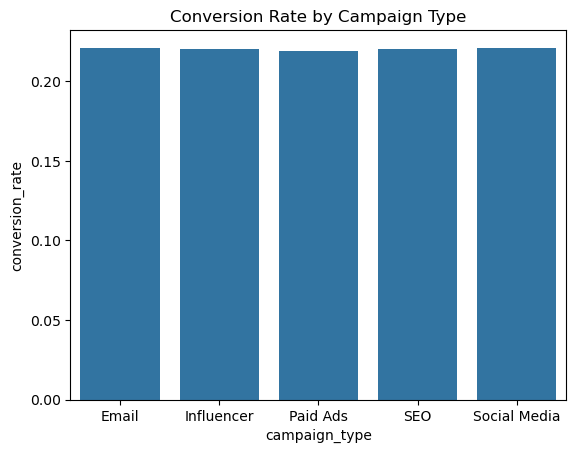

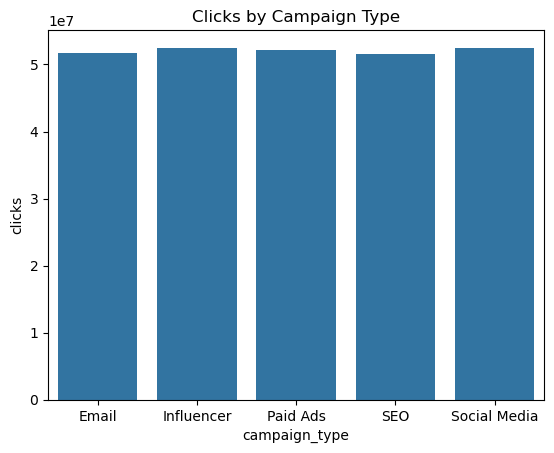

In [14]:
sns.barplot(x='campaign_type', y='conversion_rate', data=campaign_perf)
plt.title("Conversion Rate by Campaign Type")
plt.show()

sns.barplot(x='campaign_type', y='clicks', data=campaign_perf)
plt.title("Clicks by Campaign Type")
plt.show()


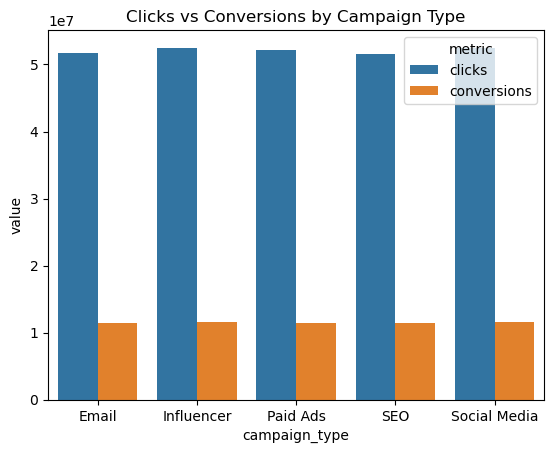

In [16]:
campaign_perf_melt = campaign_perf.melt(id_vars='campaign_type', 
                                        value_vars=['clicks','conversions'], 
                                        var_name='metric', value_name='value')

sns.barplot(x='campaign_type', y='value', hue='metric', data=campaign_perf_melt)
plt.title("Clicks vs Conversions by Campaign Type")
plt.show()


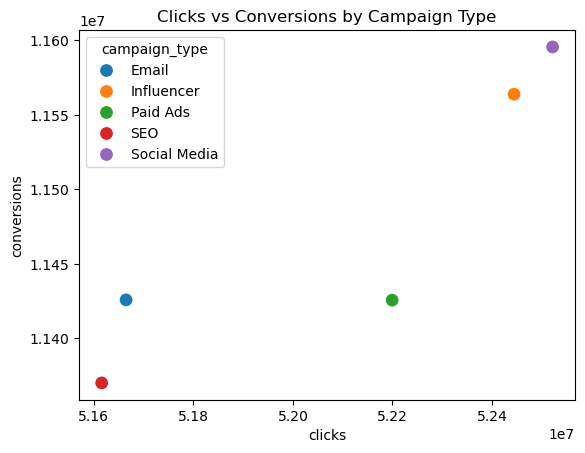

In [17]:
sns.scatterplot(x='clicks', y='conversions', hue='campaign_type', data=campaign_perf, s=100)
plt.title("Clicks vs Conversions by Campaign Type")
plt.show()


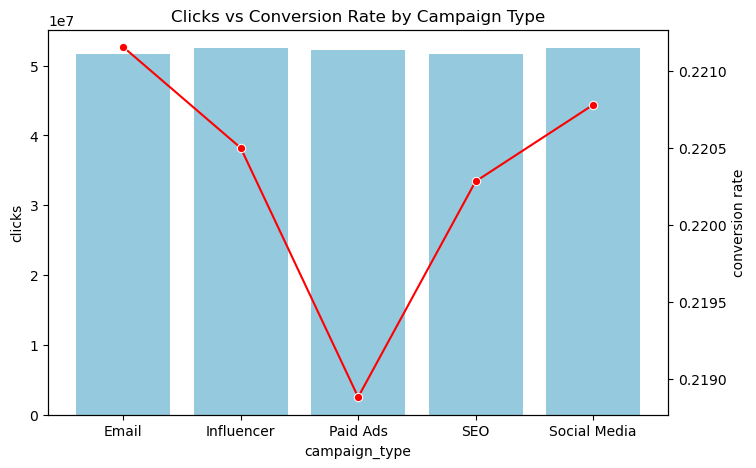

In [18]:
fig, ax1 = plt.subplots(figsize=(8,5))

sns.barplot(x='campaign_type', y='clicks', data=campaign_perf, ax=ax1, color='skyblue')
ax1.set_ylabel('clicks')

ax2 = ax1.twinx()
sns.lineplot(x='campaign_type', y='conversion_rate', data=campaign_perf, ax=ax2, color='red', marker='o')
ax2.set_ylabel('conversion rate')

plt.title("Clicks vs Conversion Rate by Campaign Type")
plt.show()


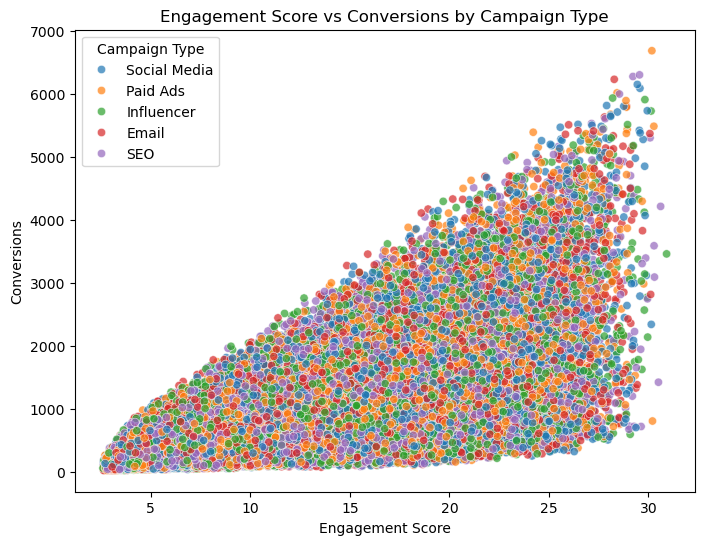

In [19]:
# Scatter plot: Engagement vs Conversions
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='engagement_score',
    y='conversions',
    hue='campaign_type',
    data=mk_cp,
    alpha=0.7
)
plt.title("Engagement Score vs Conversions by Campaign Type")
plt.xlabel("Engagement Score")
plt.ylabel("Conversions")
plt.legend(title="Campaign Type")
plt.show()




In [20]:
# Correlation check
corr = mk_cp[['engagement_score','conversions']].corr()
print("Correlation between Engagement Score and Conversions:\n", corr)


Correlation between Engagement Score and Conversions:
                   engagement_score  conversions
engagement_score          1.000000     0.643408
conversions               0.643408     1.000000


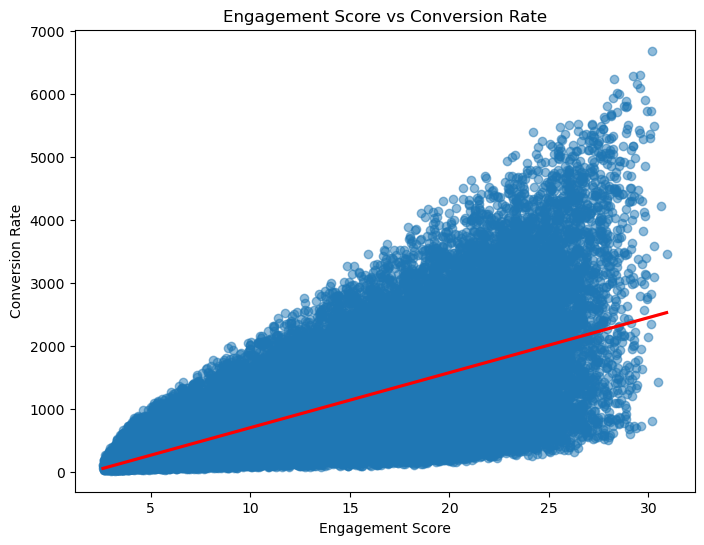

In [22]:
# Engagement vs Conversion Rate
plt.figure(figsize=(8,6))
sns.regplot(
    x='engagement_score',
    y='conversions',
    data=mk_cp,
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)
plt.title("Engagement Score vs Conversion Rate")
plt.xlabel("Engagement Score")
plt.ylabel("Conversion Rate")
plt.show()

In [24]:
# Create conversion_rate column if not already present
mk_cp['conversion_rate'] = mk_cp.apply(
    lambda row: row['conversions']/row['leads'] if row['leads'] > 0 else 0,
    axis=1
)

In [26]:
# Group by customer segment and calculate key metrics
segment_perf = mk_cp.groupby('customer_segment').agg({
    'impressions':'sum',
    'clicks':'sum',
    'leads':'sum',
    'conversions':'sum',
    'revenue':'sum',
    'acquisition_cost':'mean',
    'roi':'mean',
    'engagement_score':'mean',
    'conversion_rate':'mean'
}).reset_index()

print(segment_perf)

        customer_segment  impressions    clicks     leads  conversions  \
0       College Students    619326103  52470971  21060710     11583642   
1       Premium Shoppers    609205395  51748500  20755885     11445494   
2  Tier 2 City Customers    604981525  51647916  20677200     11365890   
3          Working Women    616328461  52770679  21145512     11638803   
4                  Youth    610565987  51807691  20652490     11347093   

      revenue  acquisition_cost       roi  engagement_score  conversion_rate  
0  5799502690        379.002159  2.699205         13.754202         0.549884  
1  5709910379        377.775364  2.720461         13.733730         0.551391  
2  5691846274        376.935257  2.699197         13.833467         0.550391  
3  5811927015        377.588823  2.771055         13.873177         0.549722  
4  5643177924        375.399928  2.679097         13.726836         0.549188  


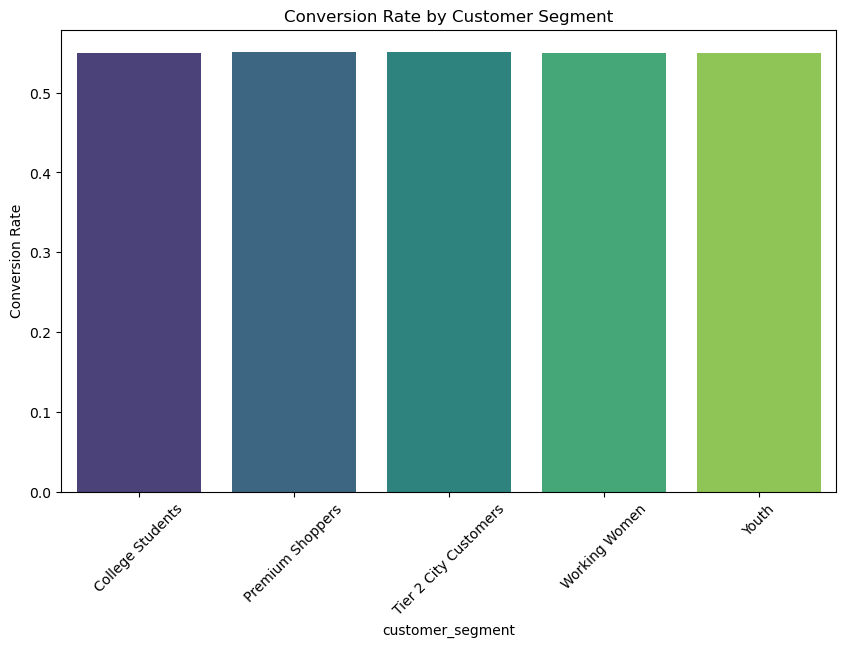

In [27]:
# Barplot: Conversion Rate by Customer Segment
plt.figure(figsize=(10,6))
sns.barplot(x='customer_segment', y='conversion_rate', data=segment_perf, palette='viridis')
plt.title("Conversion Rate by Customer Segment")
plt.xticks(rotation=45)
plt.ylabel("Conversion Rate")
plt.show()

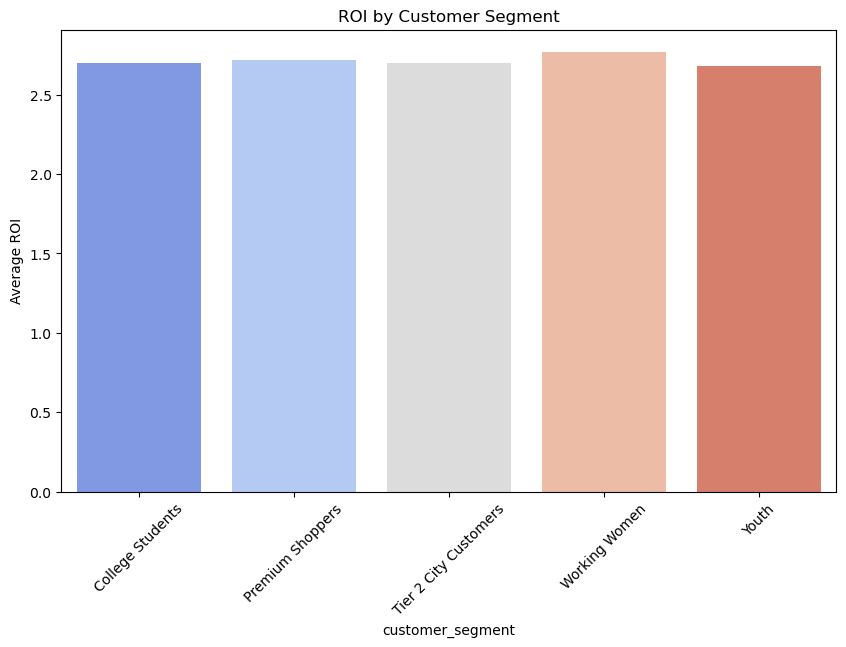

In [28]:
# Barplot: ROI by Customer Segment
plt.figure(figsize=(10,6))
sns.barplot(x='customer_segment', y='roi', data=segment_perf, palette='coolwarm')
plt.title("ROI by Customer Segment")
plt.xticks(rotation=45)
plt.ylabel("Average ROI")
plt.show()

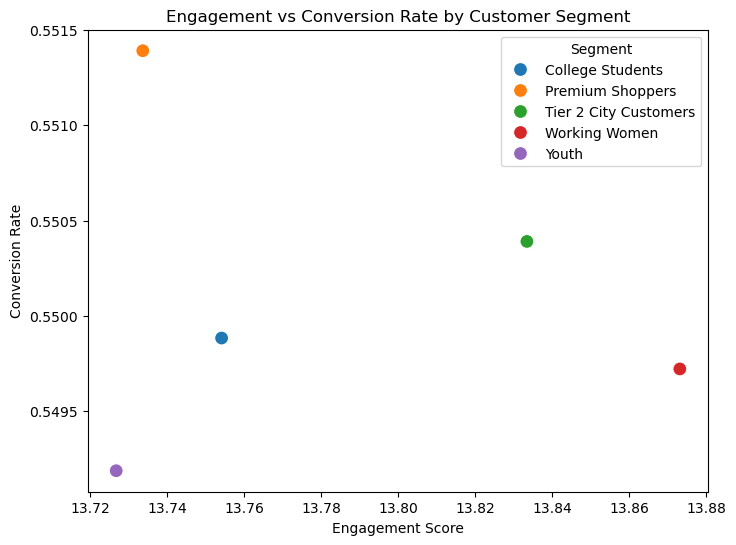

In [29]:

# Scatterplot: Engagement vs Conversion Rate by Segment
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='engagement_score',
    y='conversion_rate',
    hue='customer_segment',
    data=segment_perf,
    s=100
)
plt.title("Engagement vs Conversion Rate by Customer Segment")
plt.xlabel("Engagement Score")
plt.ylabel("Conversion Rate")
plt.legend(title="Segment")
plt.show()


Paid Ads mean conversion rate: 0.5491075208776162
Influencer mean conversion rate: 0.550180691935303
T-test result: t-stat = -0.5509906974268182 , p-value = 0.5816455846014772


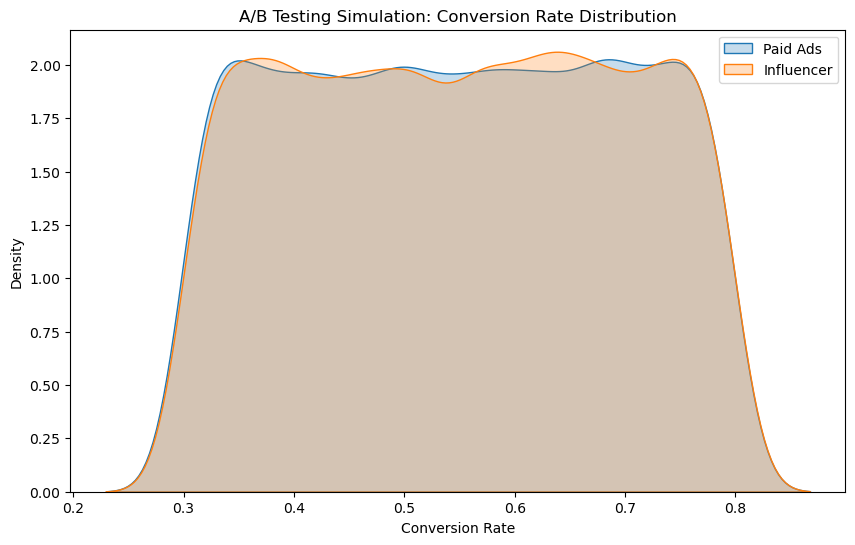

In [33]:
# AB TESTING



# Filter the two campaign types
paid_ads = mk_cp[mk_cp['campaign_type'] == 'Paid Ads']
influencer = mk_cp[mk_cp['campaign_type'] == 'Influencer']

# Calculate conversion_rate if not present
mk_cp['conversion_rate'] = mk_cp.apply(
    lambda row: row['conversions']/row['leads'] if row['leads'] > 0 else 0,
    axis=1
)

# Compare mean conversion rates
print("Paid Ads mean conversion rate:", paid_ads['conversion_rate'].mean())
print("Influencer mean conversion rate:", influencer['conversion_rate'].mean())

# Perform independent t-test
t_stat, p_val = stats.ttest_ind(paid_ads['conversion_rate'], influencer['conversion_rate'], equal_var=False)
print("T-test result: t-stat =", t_stat, ", p-value =", p_val)

#  Visualize distributions
plt.figure(figsize=(10,6))
sns.kdeplot(paid_ads['conversion_rate'], label='Paid Ads', shade=True)
sns.kdeplot(influencer['conversion_rate'], label='Influencer', shade=True)
plt.title("A/B Testing Simulation: Conversion Rate Distribution")
plt.xlabel("Conversion Rate")
plt.ylabel("Density")
plt.legend()
plt.show()




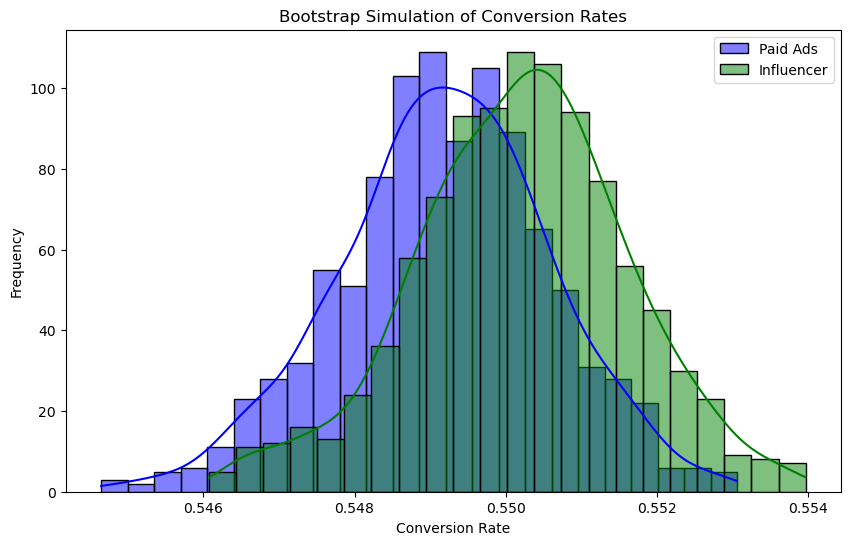

In [34]:
#  Bootstrap simulation (optional)
def bootstrap_mean(data, n_bootstrap=1000):
    boot_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))
    return boot_means

paid_boot = bootstrap_mean(paid_ads['conversion_rate'].values)
influencer_boot = bootstrap_mean(influencer['conversion_rate'].values)

plt.figure(figsize=(10,6))
sns.histplot(paid_boot, color='blue', label='Paid Ads', kde=True)
sns.histplot(influencer_boot, color='green', label='Influencer', kde=True)
plt.title("Bootstrap Simulation of Conversion Rates")
plt.xlabel("Conversion Rate")
plt.ylabel("Frequency")
plt.legend()
plt.show()


  channel_used_split       roi     revenue  acquisition_cost  conversions
3          Instagram  2.736472  9564113010        374.952014     19226869
0              Email  2.731065  9519798466        371.071016     19005771
5            YouTube  2.716941  9573677663        378.740331     19212066
2             Google  2.714173  9581611838        379.166252     19080560
1           Facebook  2.702674  9445844772        380.115407     18931319
4           WhatsApp  2.700602  9557967220        376.447908     19157633


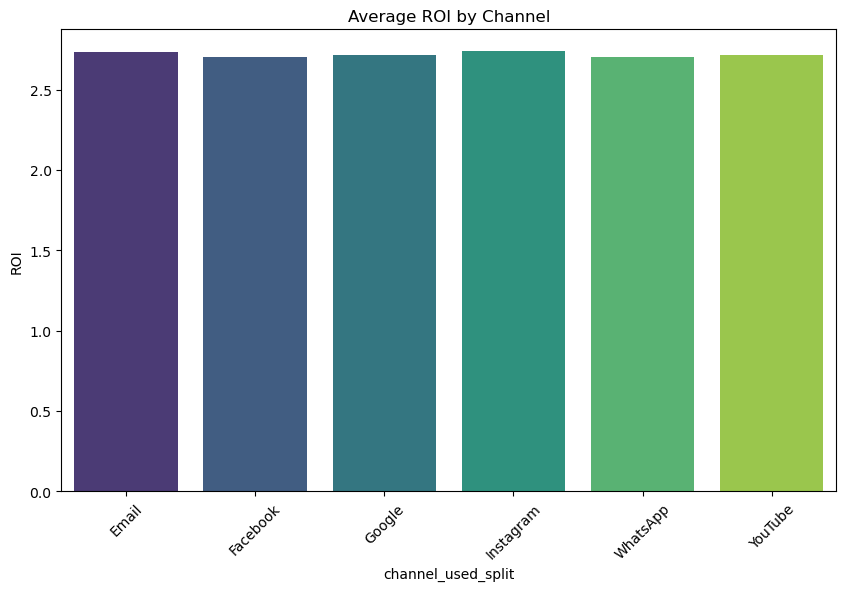

In [38]:
# Cahnnel Efficiency Report(Goal: Find which platforms (YouTube, Facebook, Instagram, WhatsApp, Google, etc.) consistently deliver high ROI.)
# Split channels if multiple are listed
mk_cp['channel_used_split'] = mk_cp['channel_used'].str.split(',')

# Explode into separate rows per channel
channels_df = mk_cp.explode('channel_used_split')
channels_df['channel_used_split'] = channels_df['channel_used_split'].str.strip()

# Group by channel and calculate average ROI
channel_efficiency = channels_df.groupby('channel_used_split').agg({
    'roi':'mean',
    'revenue':'sum',
    'acquisition_cost':'mean',
    'conversions':'sum'
}).reset_index()

print(channel_efficiency.sort_values(by='roi', ascending=False))

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(x='channel_used_split', y='roi', data=channel_efficiency, palette='viridis')
plt.title("Average ROI by Channel")
plt.xticks(rotation=45)
plt.ylabel("ROI")
plt.show()


        customer_segment       roi  conversion_rate     revenue  \
3          Working Women  2.771055         0.549722  5811927015   
1       Premium Shoppers  2.720461         0.551391  5709910379   
0       College Students  2.699205         0.549884  5799502690   
2  Tier 2 City Customers  2.699197         0.550391  5691846274   
4                  Youth  2.679097         0.549188  5643177924   

   engagement_score  
3         13.873177  
1         13.733730  
0         13.754202  
2         13.833467  
4         13.726836  


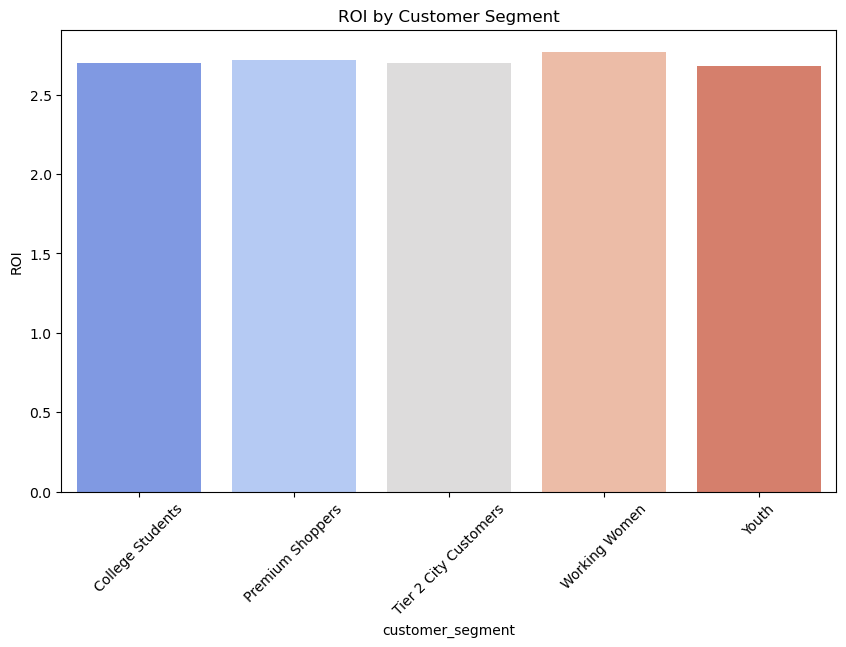

In [39]:
# Audience Targeting Strategy(Goal: Identify which customer segments should be prioritized.)
segment_perf = mk_cp.groupby('customer_segment').agg({
    'roi':'mean',
    'conversion_rate':'mean',
    'revenue':'sum',
    'engagement_score':'mean'
}).reset_index()

print(segment_perf.sort_values(by='roi', ascending=False))

# Visualization
plt.figure(figsize=(10,6))
sns.barplot(x='customer_segment', y='roi', data=segment_perf, palette='coolwarm')
plt.title("ROI by Customer Segment")
plt.xticks(rotation=45)
plt.ylabel("ROI")
plt.show()


        campaign_id campaign_type                 channel_used  \
12      NY-CMP-1012         Email   Email, Instagram, Facebook   
15      NY-CMP-1015      Paid Ads   Facebook, Instagram, Email   
17      NY-CMP-1017      Paid Ads   Google, YouTube, Instagram   
20      NY-CMP-1020      Paid Ads              Google, YouTube   
21      NY-CMP-1021           SEO   Instagram, YouTube, Google   
...             ...           ...                          ...   
55531  NY-CMP-56531    Influencer  Facebook, YouTube, WhatsApp   
55533  NY-CMP-56533    Influencer            Instagram, Google   
55534  NY-CMP-56534         Email   Instagram, Google, YouTube   
55544  NY-CMP-56544           SEO                        Email   
55546  NY-CMP-56546           SEO           Instagram, YouTube   

       acquisition_cost   roi  
12               462.62  0.52  
15              1648.61 -0.87  
17               448.86  0.21  
20              1124.19 -0.39  
21               516.25 -0.22  
...            

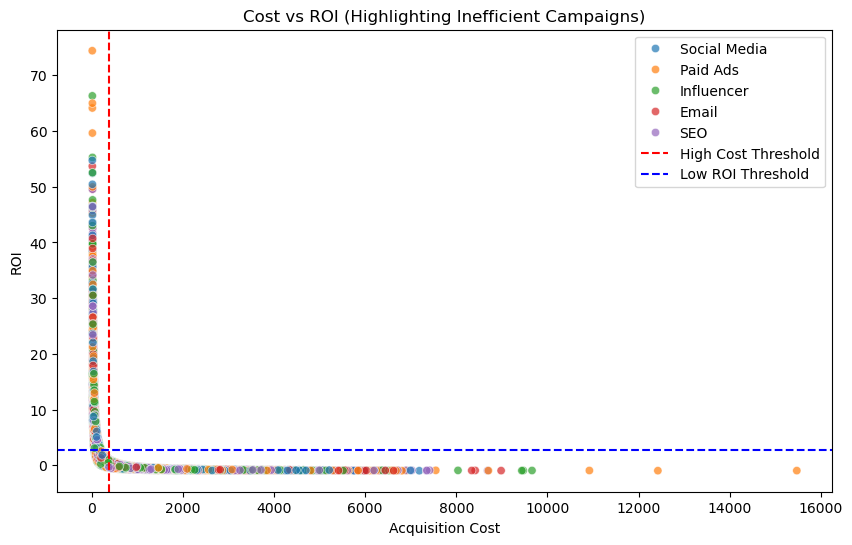

In [40]:
# Cost Optimization (Goal: Identify campaigns with high acquisition cost but low ROI.)

# Define threshold for "high cost" and "low ROI"
high_cost_threshold = mk_cp['acquisition_cost'].mean()
low_roi_threshold = mk_cp['roi'].mean()

# Filter campaigns
cost_inefficient = mk_cp[(mk_cp['acquisition_cost'] > high_cost_threshold) & 
                         (mk_cp['roi'] < low_roi_threshold)]

print(cost_inefficient[['campaign_id','campaign_type','channel_used','acquisition_cost','roi']])

# Visualization
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='acquisition_cost',
    y='roi',
    hue='campaign_type',
    data=mk_cp,
    alpha=0.7
)
plt.axvline(high_cost_threshold, color='red', linestyle='--', label='High Cost Threshold')
plt.axhline(low_roi_threshold, color='blue', linestyle='--', label='Low ROI Threshold')
plt.title("Cost vs ROI (Highlighting Inefficient Campaigns)")
plt.xlabel("Acquisition Cost")
plt.ylabel("ROI")
plt.legend()
plt.show()
